In [ ]:
# Audio Exploration: ASVspoof 2019 LA

#This notebook explores a balanced subset of the ASVspoof 2019 Logical Access dataset.

#The goal is to visually compare bonafide and spoof audio samples using:

#- label distribution
#- waveform visualization
#- mel spectrogram visualization

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

from config import SUBSET_CSV, ASVSPOOF_TRAIN_FLAC_DIR, SAMPLE_RATE
from utils import get_audio_path, load_subset

In [2]:
## Load the Balanced Subset

#The original training split is imbalanced, so this project uses a balanced subset with 1,000 bonafide and 1,000 spoof samples.

In [3]:
subset_df = load_subset(SUBSET_CSV)
subset_df.head()

,speaker_id,audio_file,unused,system_id,label,label_id
0,LA_0086,LA_T_9334813,-,A01,spoof,1
1,LA_0081,LA_T_4513430,-,-,bonafide,0
2,LA_0085,LA_T_9682976,-,A06,spoof,1
3,LA_0091,LA_T_7239632,-,-,bonafide,0
4,LA_0096,LA_T_7082730,-,A01,spoof,1


In [4]:
subset_df["label"].value_counts()

label
spoof       1000
bonafide    1000
Name: count, dtype: int64

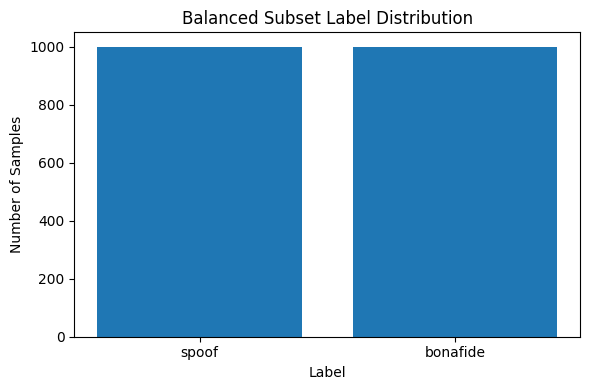

In [5]:
label_counts = subset_df["label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.title("Balanced Subset Label Distribution")
plt.tight_layout()
plt.show()

In [6]:
## Select One Bonafide and One Spoof Sample

#We select one genuine speech sample and one spoofed speech sample from the balanced subset.

In [7]:
bonafide_row = subset_df[subset_df["label"] == "bonafide"].iloc[0]
spoof_row = subset_df[subset_df["label"] == "spoof"].iloc[0]

bonafide_row, spoof_row

(speaker_id         LA_0081
 audio_file    LA_T_4513430
 unused                   -
 system_id                -
 label             bonafide
 label_id                 0
 Name: 1, dtype: object,
 speaker_id         LA_0086
 audio_file    LA_T_9334813
 unused                   -
 system_id              A01
 label                spoof
 label_id                 1
 Name: 0, dtype: object)

In [8]:
bonafide_path = get_audio_path(ASVSPOOF_TRAIN_FLAC_DIR, bonafide_row["audio_file"])
spoof_path = get_audio_path(ASVSPOOF_TRAIN_FLAC_DIR, spoof_row["audio_file"])

bonafide_audio, sr = librosa.load(bonafide_path, sr=SAMPLE_RATE, mono=True)
spoof_audio, _ = librosa.load(spoof_path, sr=SAMPLE_RATE, mono=True)

bonafide_path, spoof_path

c:\Users\aysel\asvspoof-audio-deepfake-detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(WindowsPath('C:/Users/aysel/asvspoof-audio-deepfake-detector/data/raw/ASVspoof2019_LA_train/flac/LA_T_4513430.flac'),
 WindowsPath('C:/Users/aysel/asvspoof-audio-deepfake-detector/data/raw/ASVspoof2019_LA_train/flac/LA_T_9334813.flac'))

In [9]:
## Waveform Comparison

#A waveform shows how the audio amplitude changes over time.

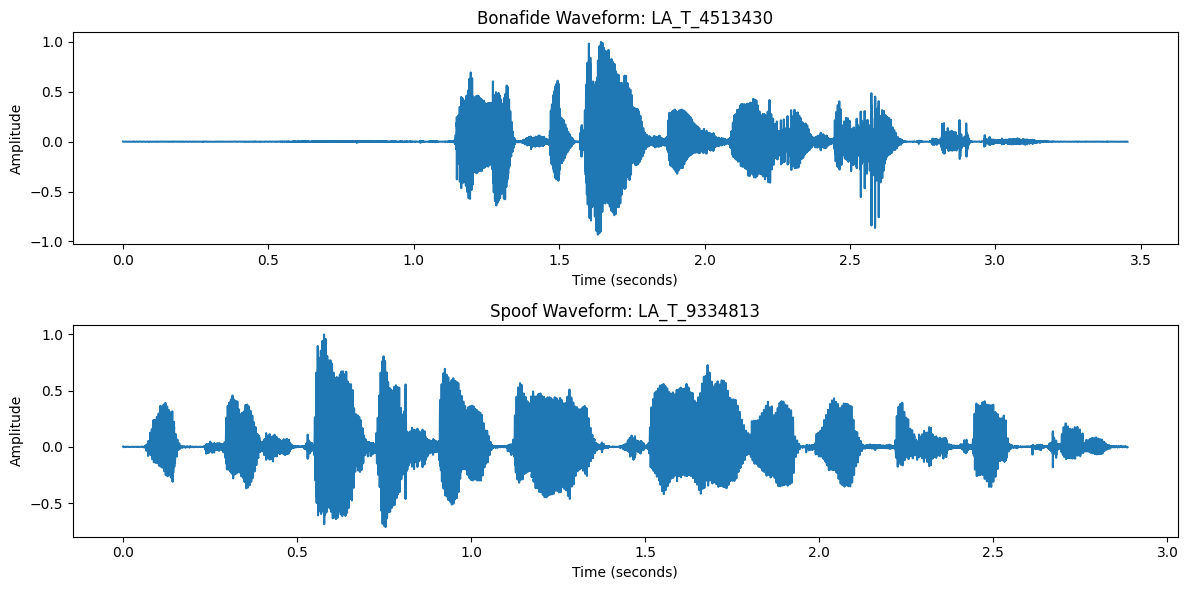

In [10]:
time_bonafide = np.arange(len(bonafide_audio)) / sr
time_spoof = np.arange(len(spoof_audio)) / sr

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time_bonafide, bonafide_audio)
plt.title(f"Bonafide Waveform: {bonafide_row['audio_file']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(time_spoof, spoof_audio)
plt.title(f"Spoof Waveform: {spoof_row['audio_file']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [11]:
## Mel Spectrogram Comparison

#A mel spectrogram shows how frequency energy changes over time. This representation is more informative than the raw waveform for many audio machine learning tasks.

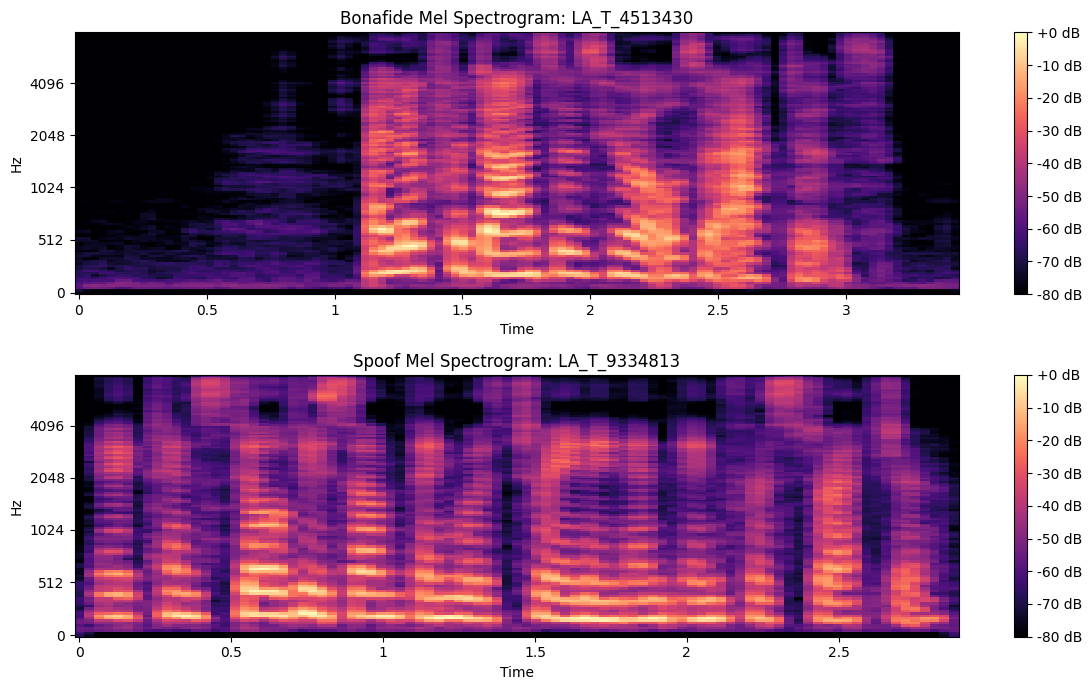

In [12]:
bonafide_mel = librosa.feature.melspectrogram(
    y=bonafide_audio,
    sr=sr,
    n_mels=128,
)

spoof_mel = librosa.feature.melspectrogram(
    y=spoof_audio,
    sr=sr,
    n_mels=128,
)

bonafide_mel_db = librosa.power_to_db(bonafide_mel, ref=np.max)
spoof_mel_db = librosa.power_to_db(spoof_mel, ref=np.max)

plt.figure(figsize=(12, 7))

plt.subplot(2, 1, 1)
librosa.display.specshow(
    bonafide_mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Bonafide Mel Spectrogram: {bonafide_row['audio_file']}")

plt.subplot(2, 1, 2)
librosa.display.specshow(
    spoof_mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spoof Mel Spectrogram: {spoof_row['audio_file']}")

plt.tight_layout()
plt.show()

In [13]:
## Initial Observations

#The waveform gives a general view of amplitude changes over time, while the mel spectrogram provides a clearer time-frequency representation.

#In this project, the actual classification is not based on visual inspection. Instead, MFCC, delta, and delta-delta features are extracted from each audio sample and used to train machine learning models.